## Step 0 — Setup

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
print("pandas:", pd.__version__)

pandas: 2.3.3


## Step 1 — Upload `ico_coffee_long_with_population.csv`

In [18]:
try:
    from google.colab import files
    print("Running in Colab — select ico_coffee_long_with_population.csv...")
    uploaded = files.upload()
except ImportError:
    print("Not running in Colab — make sure the file is already in the working directory.")

DATA_PATH = Path("ico_coffee_long_with_population.csv")
assert DATA_PATH.exists(), f"{DATA_PATH} not found — upload it in the cell above."


Not running in Colab — make sure the file is already in the working directory.


## Step 2 — Load, filter to Thailand, compute per-capita

In [19]:
df = pd.read_csv(DATA_PATH)

th = df[(df.Country == "Thailand") & (df.Metric == "domestic_consumption_kg")].copy()
th = th.sort_values("Year")
th["per_capita_kg"] = th["value"] / th["population"]

print(f"{len(th)} years of data, {int(th.Year.min())}-{int(th.Year.max())}")
th[["Year", "value", "population", "per_capita_kg"]].head()

30 years of data, 1990-2019


,Year,value,population,per_capita_kg
1350,1990.0,11280000.0,54738329.0,0.206071
1351,1991.0,13200000.0,55637434.0,0.237250
1352,1992.0,13980000.0,56528834.0,0.247307
1353,1993.0,15000000.0,57408198.0,0.261287
1354,1994.0,16980000.0,58260854.0,0.291448


## Step 3 — Plot

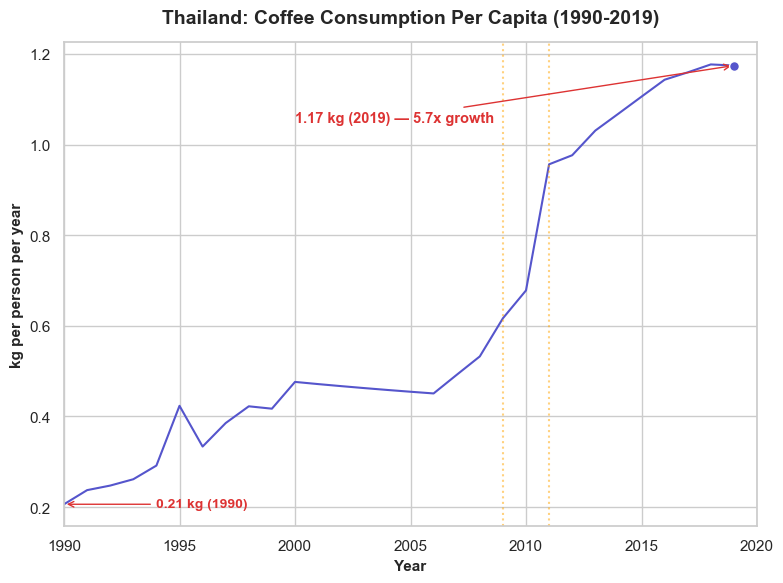

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(data=th, x="Year", y="per_capita_kg", ax=ax,
             color="#5555CC", linewidth=1.5)

ax.set_title("Thailand: Coffee Consumption Per Capita (1990-2019)", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Year", fontsize=11,fontweight="bold")
ax.set_ylabel("kg per person per year", fontsize=11,fontweight="bold")
ax.set_xlim(1990, 2019)

first_row = th.iloc[0]
last_row = th.iloc[-1]

growth_x = last_row["per_capita_kg"] / first_row["per_capita_kg"]
xticks = sorted(set(list(range(1990, 2020, 5)) + [2020]))
ax.set_xticks(xticks)
for yr in [2009, 2011]:
    ax.axvline(x=yr, color="orange", linestyle=":", linewidth=1.5,alpha=0.5)

ax.annotate(f"{first_row['per_capita_kg']:.2f} kg ({int(first_row['Year'])})",
            xy=(first_row["Year"], first_row["per_capita_kg"]),
            xytext=(1994, first_row["per_capita_kg"]),
            fontsize=10, color="#DD3333", fontweight="bold", va="center",
            arrowprops=dict(arrowstyle="->", color="#DD3333"))

ax.scatter([last_row["Year"]], [last_row["per_capita_kg"]],
           color="#5555CC", s=50, zorder=5, edgecolor="white", linewidth=1)

ax.annotate(f"{last_row['per_capita_kg']:.2f} kg ({int(last_row['Year'])}) \u2014 {growth_x:.1f}x growth",
            xy=(last_row["Year"], last_row["per_capita_kg"]), xytext=(2000, 1.05),
            fontsize=10.5, color="#DD3333", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#DD3333"))


plt.tight_layout()
plt.savefig("thailand_per_capita_consumption_simple.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## Step 4 — Download the chart (Colab only)

In [22]:
try:
    from google.colab import files as _colab_files
    _colab_files.download("thailand_per_capita_consumption_simple.png")
except ImportError:
    print(f"Not in Colab — find it locally at: {Path('thailand_per_capita_consumption_simple.png').resolve()}")

Not in Colab — find it locally at: C:\Users\KrissW Laptop\Downloads\graph\consump per capita\thailand_per_capita_consumption_simple.png
